In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import netcdf
import netCDF4 as nc
# fname 为 你下载的字体库路径，注意 SourceHanSansSC-Bold.otf 字体的路径
import matplotlib
zhfont1 = matplotlib.font_manager.FontProperties(fname=r"/home/zhangzhibo/font/SourceHanSansSC-Bold.otf") 


In [90]:
file_path_base = r'/home/zhangzhibo/serghei/serghei-gw-transport-ing/test/benchmark/t4-NonlinearEquilibriumSorption/'
subsurface_file_path = file_path_base + r'out-111/output_subsurface.nc'
subsurface_dataset =  nc.Dataset(subsurface_file_path, 'r') # 'r' 表示只读模式
wc_out = subsurface_dataset.variables['wc'][:]
h_out = subsurface_dataset.variables['hd'][:]
qx_out = subsurface_dataset.variables['qx'][:]
qy_out = subsurface_dataset.variables['qy'][:]
qz_out = subsurface_dataset.variables['qz'][:]
# subsurface_dataset

In [91]:
# 打开NetCDF文件
file_path = file_path_base + r'out-111/output_transport.nc'
dataset = nc.Dataset(file_path, 'r')
c_out = dataset.variables['c'][:]
cs_out = dataset.variables['c_solid'][:]
file_path2 = file_path_base + r'out-222/output_transport.nc'
dataset2 = nc.Dataset(file_path2, 'r')
c_out2 = dataset2.variables['c'][:]
cs_out2 = dataset2.variables['c_solid'][:]
# file_path5 = r'/home/zhangzhibo/serghei/serghei-gw-transport-upstreamWeighting/test/t6-irrigation-rtgbc/out-333-picard-nokernels/output_transport.nc'
# dataset5= nc.Dataset(file_path5, 'r')
# c_out5 = dataset5.variables['c'][:]
dataset



<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    dimensions(sizes): t(101), x(1), y(1), z(200)
    variables(dimensions): float64 t(t), float64 x(x), float64 y(y), float64 z(z), float64 z3d(z, y, x), float64 c(t, z, y, x), float64 c_solid(t, z, y, x), float64 c_difxz(t, z, y, x), float64 c_difzx(t, z, y, x), float64 c_difxx(t, z, y, x), float64 c_difzz(t, z, y, x)
    groups: 

In [92]:
print("t=0",np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:])),
print("t=1",np.sum (c_out[1,:,:,:]*wc_out[1,:,:,:])),
print("t=-1",np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])),
print("t=-2 - t=-1",np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[-2,:,:,:]*wc_out[-2,:,:,:]))
print("precent",(np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))/np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))

t=0 0.0
t=1 27.11857108290707
t=-1 689.3586232345093
t=-2 - t=-1 0.0
precent inf


/tmp/ipykernel_196637/2326341391.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  print("precent",(np.sum (c_out[-1,:,:,:]*wc_out[-1,:,:,:])-np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))/np.sum (c_out[0,:,:,:]*wc_out[0,:,:,:]))


质量守恒分析

In [93]:
np.sum(c_out[0,:,:,:])


np.float64(0.0)

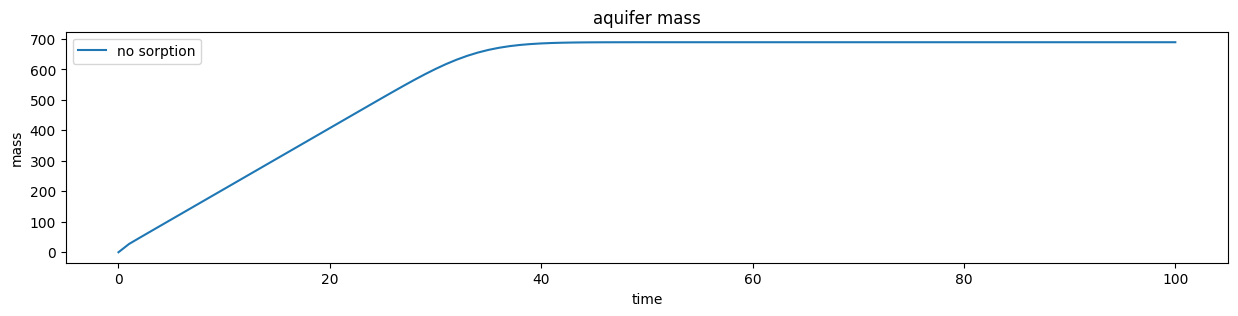

In [94]:
mass =[]
for i in range(0,c_out.shape[0]):
     mass.append(np.sum (c_out[i,:,:,:]*wc_out[i,:,:,:]))
mass2 =[]
for i in range(0,c_out2.shape[0]):
     mass2.append(np.sum (c_out2[i,:,:,:]*wc_out[i,:,:,:]))
# mass3 =[]
# for i in range(0,c_out3.shape[0]):
#      mass3.append(np.sum (c_out3[i,:,:,:]*wc_out[i,:,:,:]))
# mass4 =[]
# for i in range(0,c_out4.shape[0]):
#      mass4.append(np.sum (c_out4[i,:,:,:]*wc_out[i,:,:,:]))
# mass5 =[]
# for i in range(0,c_out5.shape[0]):
#      mass5.append(np.sum (c_out5[i,:,:,:]*wc_out[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
# plt.plot(mass2[:],label='linearly sorption',linestyle='--')
# plt.plot(mass3[:],label='no sorption-2')
# plt.plot(mass4[:],label='linearly sorption-2') 
# plt.plot(mass5[:],label='out-777-wc-gs')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('aquifer mass')
plt.legend()
plt.xlabel('time')
plt.ylabel('mass')
plt.show()

固相质量守恒

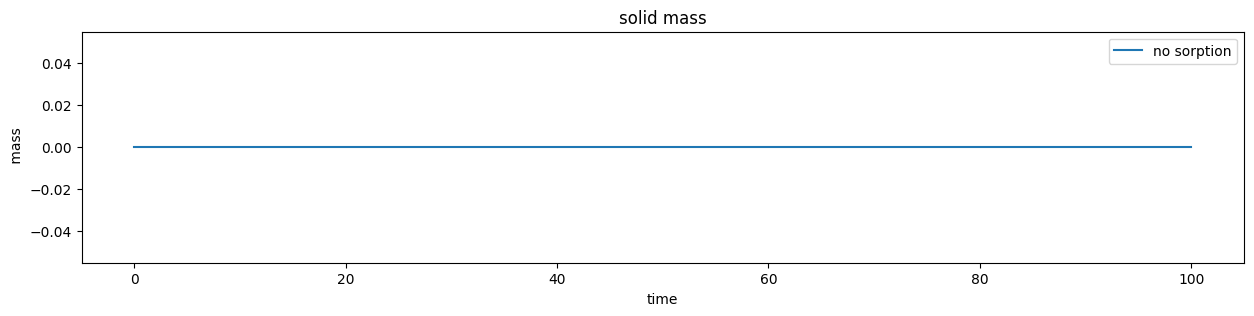

In [95]:
mass =[]
for i in range(0,cs_out.shape[0]):
     mass.append(np.sum (cs_out[i,:,:,:]))
mass2 =[]
for i in range(0,cs_out2.shape[0]):
     mass2.append(np.sum (cs_out2[i,:,:,:]))
# mass3 =[]
# for i in range(0,c_out3.shape[0]):
#      mass3.append(np.sum (c_out3[i,:,:,:]*wc_out[i,:,:,:]))
# mass4 =[]
# for i in range(0,c_out4.shape[0]):
#      mass4.append(np.sum (c_out4[i,:,:,:]*wc_out[i,:,:,:]))
# mass5 =[]
# for i in range(0,c_out5.shape[0]):
#      mass5.append(np.sum (c_out5[i,:,:,:]*wc_out[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
# plt.plot(mass2[:],label='linearly sorption',linestyle='--')
# plt.plot(mass3[:],label='no sorption-2')
# plt.plot(mass4[:],label='linearly sorption-2') 
# plt.plot(mass5[:],label='out-777-wc-gs')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('solid mass')
plt.legend()
plt.xlabel('time')
plt.ylabel(' mass')
plt.show()

水相+固相

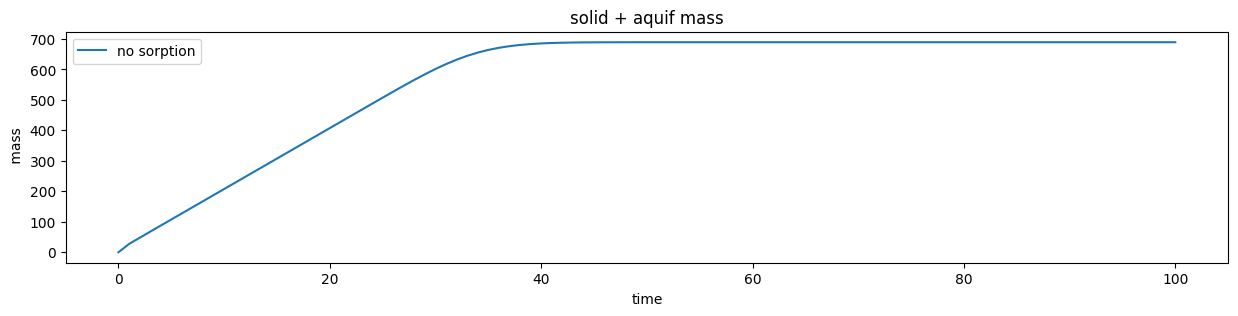

In [96]:
mass =[]
for i in range(0,cs_out.shape[0]):
     mass.append(np.sum (c_out[i,:,:,:]*wc_out[i,:,:,:]+cs_out[i,:,:,:]))
mass2 =[]
for i in range(0,cs_out2.shape[0]):
     mass2.append(np.sum (c_out2[i,:,:,:]*wc_out[i,:,:,:]+cs_out2[i,:,:,:]))
plt.figure(figsize=(15, 3),dpi=100)
plt.subplot(1, 1, 1)
plt.plot(mass[:],label='no sorption')
# plt.plot(mass2[:],label='linearly sorption',linestyle='--')
# plt.xlim(0, 100)
# plt.ylim(0, 5)
plt.ticklabel_format(axis='y', style='plain')
# y轴不使用科学计数法
plt.title('solid + aquif mass')
plt.legend()
plt.xlabel('time')
plt.ylabel(' mass')
plt.show()

In [97]:
mass[c_out.shape[0]-1],mass2[c_out.shape[0]-1]

(np.float64(689.3586232345093), np.float64(85.74481134099794))

In [98]:
t=c_out.shape[0]-1
# t=2

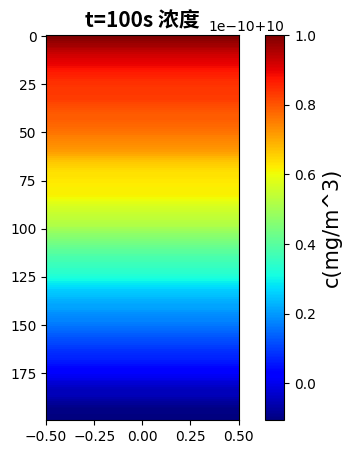

In [88]:
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.imshow((
                    c_out[t,:,:,0])
                  #   , extent=[0, 10, 0,5 ]
                    ,interpolation="nearest"   
                    ,cmap='jet'  
                     ,aspect=0.01 
                    #  , vmin=0
                    #  , vmax=1
                    )
          # plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}s 浓度".format(t), fontproperties=zhfont1,fontsize=15)
          # plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('c(mg/m^3)',fontsize=15)

# # 调整颜色条的大小
# # cbar.ax.set_aspect(10)
#   # 设置颜色条的长宽比，这里将长度设置为宽度的16倍
#     cbar.ax.set_position([0.8, 0.2, 0.2, 0.6])
# 代表colorbar的左边界、下边界、宽度、高度
plt.show()
# plt.savefig('images/4-11.png')

不同求解方法结果对比

In [66]:
t =9
ind = [0,10,20,30,40,50,60,70,80,90,c_out.shape[0]-1]

IndexError: index 50 is out of bounds for axis 0 with size 45

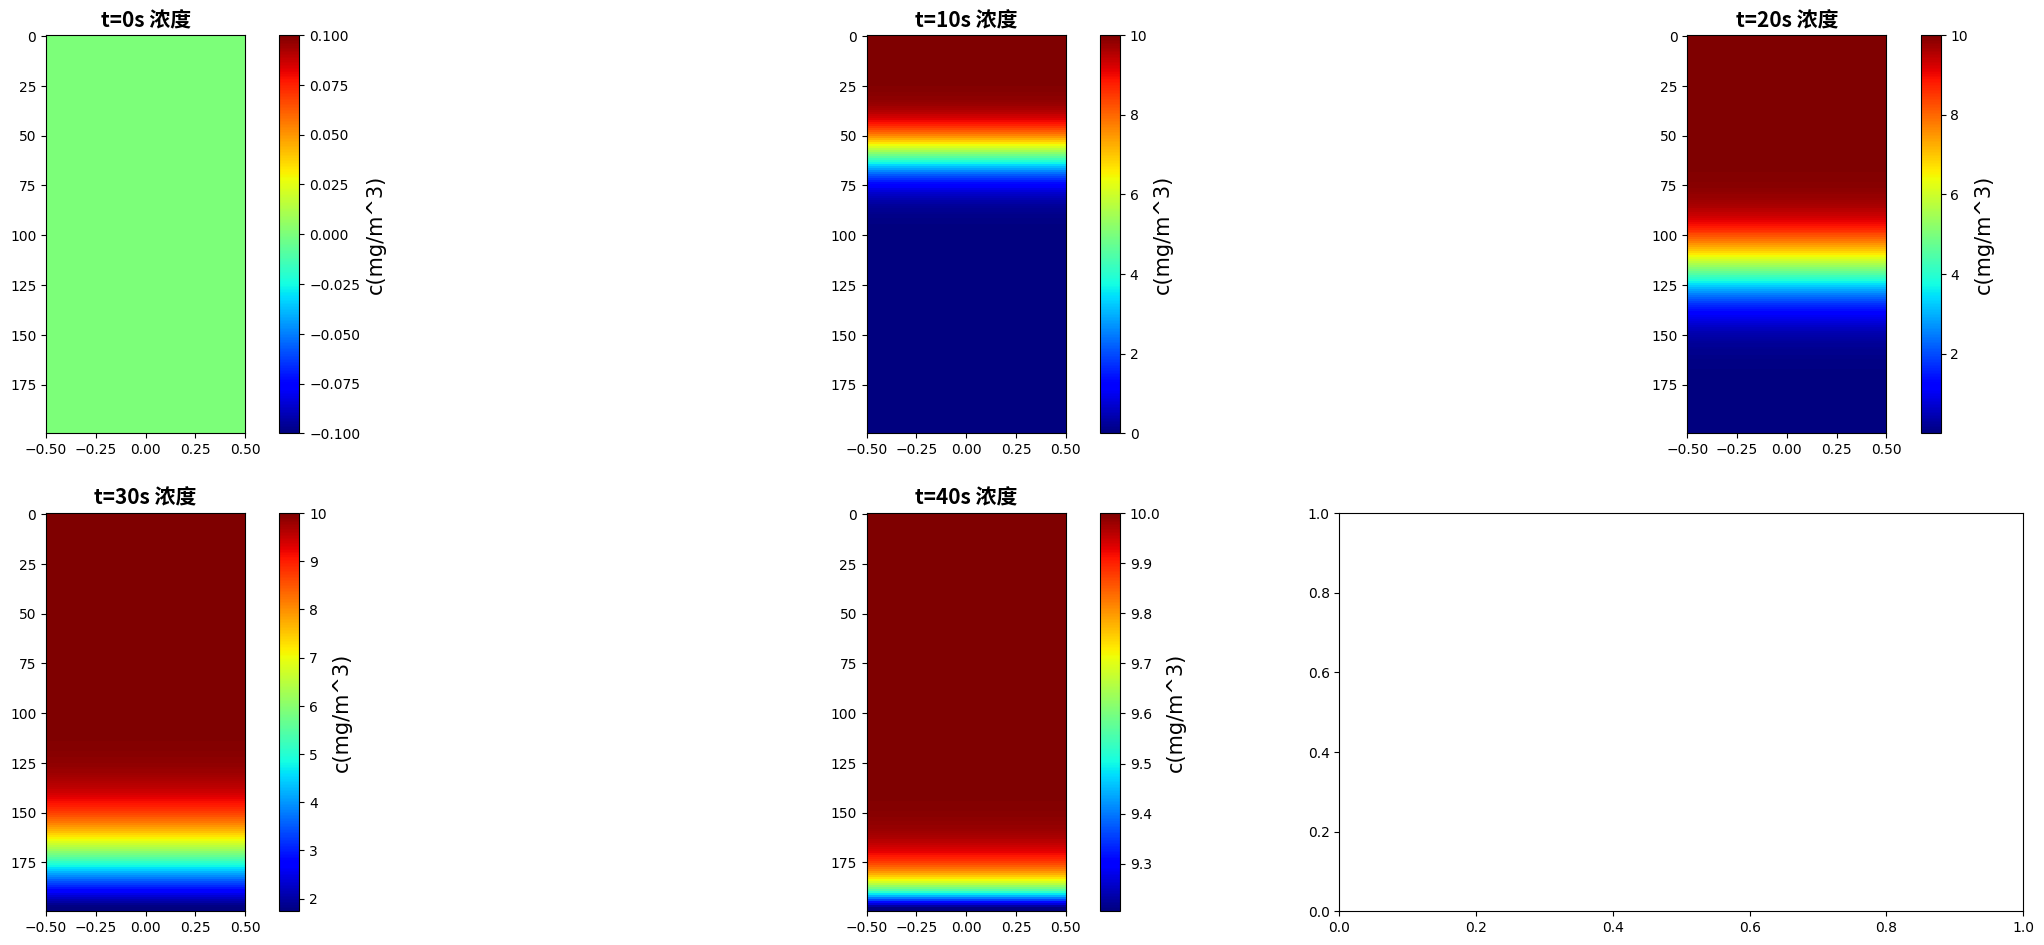

In [68]:
# 循环画每个时间点的图
plt.figure(figsize=(30, 30),dpi=100)
ifig = 1
for ii in range(int(len(ind))): 
     plt.subplot(5,3,ifig)
     # u_out[t,:,:][nonvalue_index] = 0
     # 令hz输出结果中nan值部分等于真实dem值
     plt.imshow((c_out[ind[ii],:,0,:])
               #  , extent=[0, 167*500, 0,164*500 ]#  
               ,interpolation="nearest"  
               ,cmap='jet' 
                ,aspect=0.01
               #  , vmin=0.1
               #  , vmax=1
               )
     # plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
     plt.title("t={}s 浓度".format(ind[ii]), fontproperties=zhfont1,fontsize=15)
     # plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
     cbar = plt.colorbar()
     cbar.ax.tick_params(labelsize=10)
     cbar.set_label('c(mg/m^3)',fontsize=15)
     ifig = ifig+1
# # 调整颜色条的大小
# # cbar.ax.set_aspect(10)
#   # 设置颜色条的长宽比，这里将长度设置为宽度的16倍
#     cbar.ax.set_position([0.8, 0.2, 0.2, 0.6])
# 代表colorbar的左边界、下边界、宽度、高度
plt.show()
# plt.savefig('images/4-11.png')

In [ ]:
np.min( wc_out[:,:,0,:]),np.max( wc_out[:,:,0,:])

In [22]:
t = -1

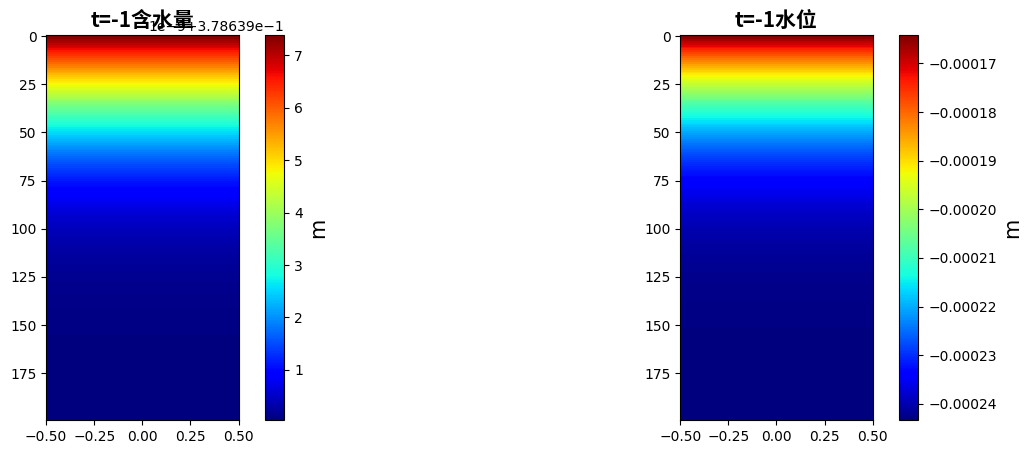

In [28]:
plt.figure(figsize=[15,5],dpi=100)
plt.subplot(1, 2, 1)
plt.imshow((wc_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
           ,aspect=0.01 
          # , vmin=-0.00002#  , vmax=0.00002
           )
# plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}含水量".format(t), fontproperties=zhfont1,fontsize=15)
# plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m',fontsize=15)
plt.subplot(1, 2, 2)
plt.imshow((h_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          ,aspect=0.01
          #, vmin=-0.00002#  
          # , vmax=0.00002
           )
# plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}水位".format(t), fontproperties=zhfont1,fontsize=15)
# plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m',fontsize=15)
# # 调整颜色条的大小
# # cbar.ax.set_aspect(10)
#   # 设置颜色条的长宽比，这里将长度设置为宽度的16倍
#     cbar.ax.set_position([0.8, 0.2, 0.2, 0.6])
# 代表colorbar的左边界、下边界、宽度、高度
# plt.savefig('images/4-11.png')
plt.show()
# plt.savefig('images/4-11.png')

地下水流速

In [24]:
t=-1

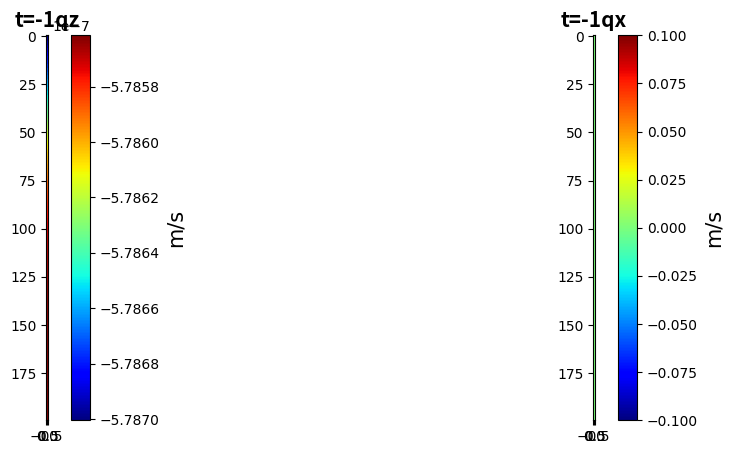

In [25]:
plt.figure(figsize=[20,5],dpi=100)
plt.subplot(1, 3, 1)
plt.imshow((qz_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          #  ,aspect=30#  , vmin=-0.00002#  , vmax=0.00002
           )
# plt.xlabel('距离 (m)', fontproperties=zhfont1,fontsize=15)
plt.title("t={}qz".format(t), fontproperties=zhfont1,fontsize=15)
# plt.xticks(np.arange(0, 1000, 500), fontsize=5, color='red' )
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m/s',fontsize=15)
plt.subplot(1, 3, 2)
plt.imshow((qx_out[t,:,0,:])
          #  , extent=[0, 167*500, 0,164*500 ]#  
          ,interpolation="nearest" #  
          ,cmap='jet' # 
          #  ,aspect=30#  , vmin=-0.00002#  , vmax=0.00002
           )
plt.title("t={}qx".format(t), fontproperties=zhfont1,fontsize=15)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=10)
cbar.set_label('m/s',fontsize=15)
# # 调整颜色条的大小
# # cbar.ax.set_aspect(10)
#   # 设置颜色条的长宽比，这里将长度设置为宽度的16倍
#     cbar.ax.set_position([0.8, 0.2, 0.2, 0.6])
# 代表colorbar的左边界、下边界、宽度、高度
plt.show()
# plt.savefig('images/4-11.png')

In [26]:
qx_out[1,0,:,:]

masked_array(data=[[0.]],
             mask=False,
       fill_value=1e+20)

IndexError: index 50 is out of bounds for axis 3 with size 1

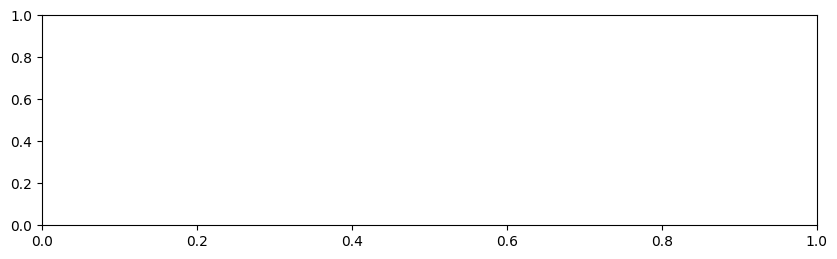

In [27]:
# 纵向浓度变化
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
# plt.plot(c_out[:,0,0,50],label='t=-1')   
plt.plot(qz_out[0,:,0,50],label='t=0',linestyle='--')
plt.plot(qz_out[1,:,0,50],label='t=-2',linestyle='--')
plt.plot(qz_out[-1,:,0,50],label='t=-1',linestyle='--')
plt.xlabel('z')
# plt.label('time')
plt.title('纵向浓度变化',fontproperties=zhfont1)
plt.legend(loc='upper right')
plt.show
